# Real-data case study — MTBLS1 (urine NMR, Type 2 Diabetes)

The earlier notebooks use cachexia, synthetic drift data, or
purpose-built factorial layouts. This one runs the full `ov.metabol`
stack on a **public, real-world dataset** straight from the
Metabolights repository: [**MTBLS1**](https://www.ebi.ac.uk/metabolights/MTBLS1),
a 600 MHz ¹H-NMR urine metabolomics study of Type 2 Diabetes
(Salek et al., *Physiol. Genomics* 2007).

- **132 samples** — 84 T2D, 48 controls
- **189 metabolite features** (~30 % named, rest are chemical-shift peaks)
- **No pooled-QC samples**, no injection-order metadata → forces us to
  fall back on the non-QC code paths (``cv_filter(across='all')``)
- **Pre-curated peak table** in the study's MAF file

Goals: (1) end-to-end workflow on data we did not generate; (2)
show which tools apply and which don't; (3) exercise every
metabol plotting helper.

Workflow:

0. download the study
1. build an AnnData
2. QC & PCA-based sample outliers
3. missing-value pattern
4. intensity distribution (raw vs PQN-normalised)
5. impute / normalise / log+Pareto
6. two-group differential + volcano
7. PLS-DA, OPLS-DA, S-plot, VIP bar
8. MSEA ORA + pathway bar
9. ASCA (group × gender) + variance-explained bar
10. biomarker: per-feature ROC + nested-CV panel + fold ROC
11. DGCA + class-count bar + per-condition correlation network
12. summary


## 0 — Setup and dataset download

The whole ISA-Tab layout (sample sheet + assay sheet + MAF file) is
fetched in one line with **`ov.utils.load_metabolights`**, which
caches files under `cache_dir` and returns a samples × metabolites
AnnData. `group_col="Factor Value[Metabolic syndrome]"` renames the
T2D vs control factor to the canonical `adata.obs['group']` so every
downstream function works out of the box.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.1.2rc1


In [2]:
adata = ov.utils.load_metabolights(
    'MTBLS1',
    group_col='Factor Value[Metabolic syndrome]',
    cache_dir='mtbls1_demo',
)
print(adata)
print('group counts:', adata.obs['group'].value_counts().to_dict())


AnnData object with n_obs × n_vars = 132 × 220
    obs: 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Organism part]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Variant]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sample type]', 'Term Source REF.3', 'Term Accession Number.3', 'Protocol REF', 'Factor Value[Gender]', 'Term Source REF.4', 'Term Accession Number.4', 'group', 'Term Source REF.5', 'Term Accession Number.5'
    var: 'metabolite_identification', 'chemical_formula', 'smiles'
    uns: 'metabolights'
group counts: {'Control Group': 84, 'diabetes mellitus': 48}


## 1 — Exploratory look

Before any cleaning, peek at the raw layout and gender breakdown so
later per-step numbers are interpretable.


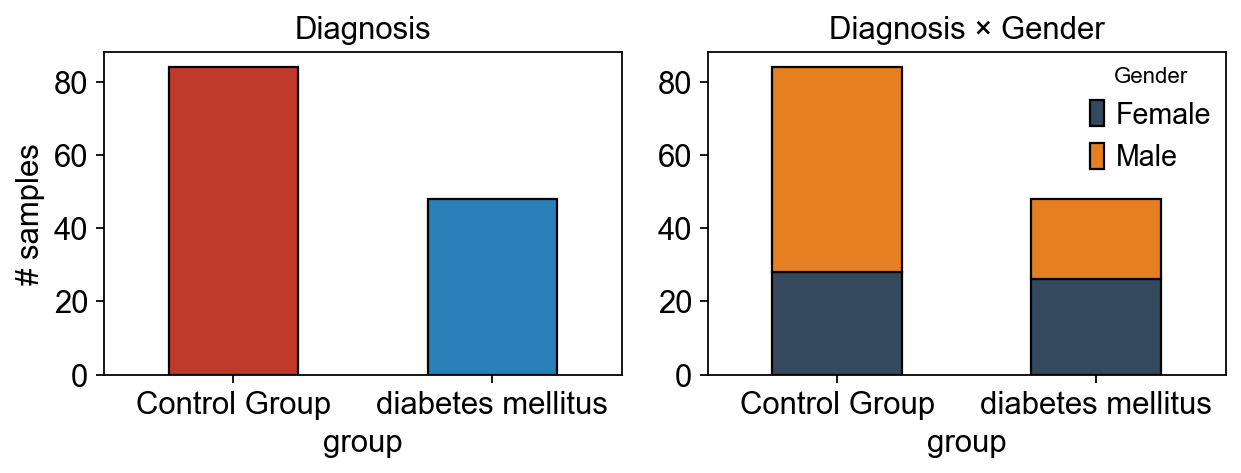

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
adata.obs['group'].value_counts().plot.bar(ax=axes[0], color=['#c0392b', '#2980b9'], edgecolor='k')
axes[0].set_title('Diagnosis')
axes[0].set_ylabel('# samples')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(adata.obs['group'], adata.obs['Factor Value[Gender]']).plot.bar(
    stacked=True, ax=axes[1], color=['#34495e', '#e67e22'], edgecolor='k')
axes[1].set_title('Diagnosis × Gender')
axes[1].legend(title='Gender', frameon=False)
axes[1].tick_params(axis='x', rotation=0)
fig.tight_layout(); plt.show()


## 2 — Sample-level outlier detection (Hotelling T² + DModX)

`sample_qc` fits a PCA on the raw matrix, computes **Hotelling's
T²** (distance inside the PC-subspace) and **DModX** (distance to
the residual plane), and flags samples that fall above either
critical value at α = 0.95. `sample_qc_plot` renders the scatter +
threshold lines in a single call.


flagged: 35 / 132


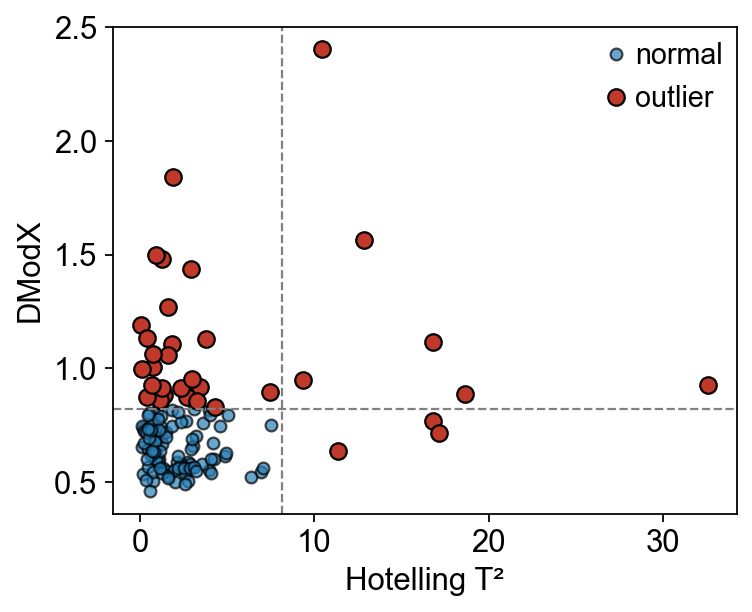

In [4]:
qc = ov.metabol.sample_qc(adata, n_components=3, alpha=0.95)
print(f'flagged: {qc["is_outlier"].sum()} / {len(qc)}')
ov.metabol.sample_qc_plot(qc)
plt.show()


## 3 — Missing-value pattern

Before imputation, check *where* the NaNs sit. For a well-designed
study the missing cells should be roughly uniform across samples —
if one sample has 10× the NaN count of the others it probably needs
dropping.


In [5]:
X = np.asarray(adata.X)
miss_per_sample = np.isnan(X).mean(axis=1)
miss_per_feature = np.isnan(X).mean(axis=0)
print(f'overall missingness: {np.isnan(X).mean():.1%}')
print(f'features with >10% NaN: {(miss_per_feature > 0.1).sum()}')


overall missingness: 0.0%
features with >10% NaN: 0


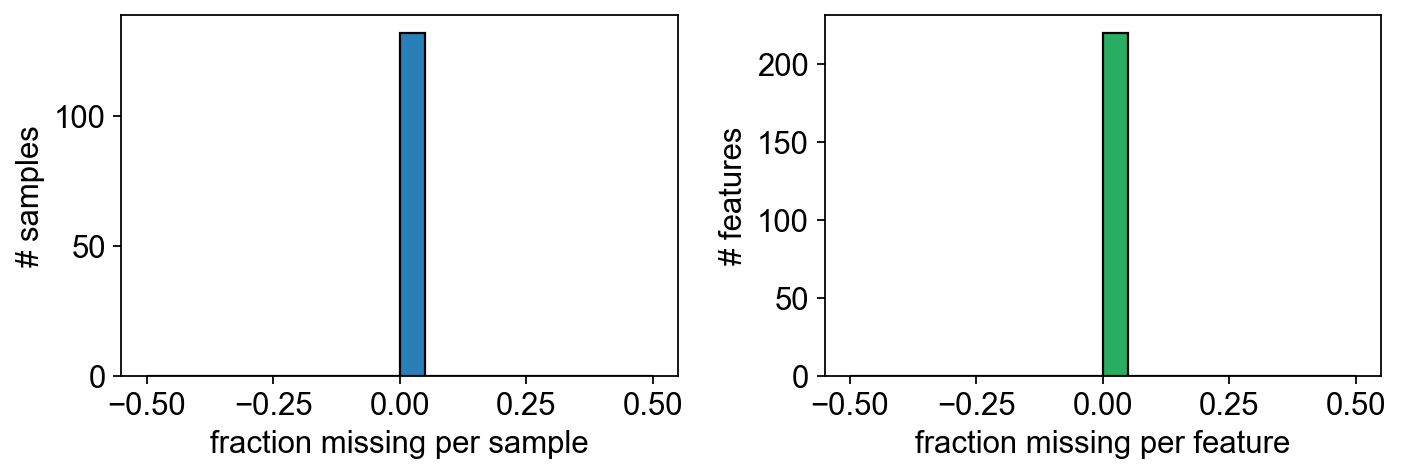

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(miss_per_sample, bins=20, color='#2980b9', edgecolor='k')
axes[0].set_xlabel('fraction missing per sample'); axes[0].set_ylabel('# samples')
axes[1].hist(miss_per_feature, bins=20, color='#27ae60', edgecolor='k')
axes[1].set_xlabel('fraction missing per feature'); axes[1].set_ylabel('# features')
fig.tight_layout(); plt.show()


## 4 — Feature filter (cv_filter across='all') + preprocessing

`cv_filter(across='all')` is the v0.5 addition for QC-less studies:
compute the CV across **every** sample (instead of pooled QC) and
drop the noisiest features. Then impute with **QRILC**, normalise
with **PQN**, log-transform, and Pareto-scale.


In [7]:
adata_cv = ov.metabol.cv_filter(adata, across='all', cv_threshold=1.5)
adata_imp = ov.metabol.impute(adata_cv, method='qrilc', seed=0)
adata_norm = ov.metabol.normalize(adata_imp, method='pqn')
adata_log = ov.metabol.transform(adata_norm, method='log')
adata_pareto = ov.metabol.transform(adata_log, method='pareto', stash_raw=False)


In [8]:
print(f'features kept by cv_filter: {adata_cv.n_vars}/{adata.n_vars}')
print(f'NaN after QRILC: {np.isnan(np.asarray(adata_imp.X)).sum()}')
print(f'Pareto max |column mean|: {np.abs(np.asarray(adata_pareto.X).mean(axis=0)).max():.2e}')


features kept by cv_filter: 194/220
NaN after QRILC: 0
Pareto max |column mean|: 3.32e-15


### 4a — Raw vs PQN-normalised intensity

A quick box-strip of per-sample median intensities before and after
PQN — after normalisation all samples should sit at roughly the
same level (the PQN assumption).


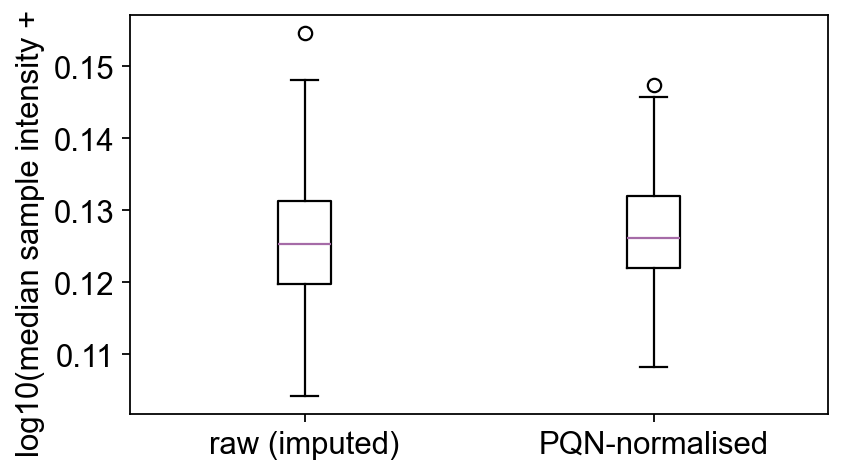

In [9]:
raw_med = np.log10(np.nanmedian(np.asarray(adata_imp.X), axis=1) + 1)
norm_med = np.log10(np.nanmedian(np.asarray(adata_norm.X), axis=1) + 1)
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.boxplot([raw_med, norm_med], labels=['raw (imputed)', 'PQN-normalised'])
ax.set_ylabel('log10(median sample intensity + 1)')
fig.tight_layout(); plt.show()


## 5 — Two-group differential analysis (Welch's t)

PQN + log is the MetaboAnalyst canonical pipeline; we ran it above.
`differential` on the log-transformed AnnData gives per-feature
**Welch's t**, p-values, BH-FDR, and log2-fold changes.


In [10]:
deg = ov.metabol.differential(
    adata_log,
    group_col='group',
    group_a='diabetes mellitus',
    group_b='Control Group',
    method='welch_t',
    log_transformed=True,
)
print(f'{(deg["padj"] < 0.05).sum()}/{len(deg)} features padj<0.05')


78/194 features padj<0.05


In [11]:
top = deg.sort_values('pvalue').head(8).copy()
top['name'] = adata_cv.var.loc[top.index, 'metabolite_identification'].values
top[['name', 'stat', 'pvalue', 'padj', 'log2fc']]


                              name      stat        pvalue          padj  \
m59                     isoleucine -9.291729  4.663572e-16  4.523665e-14   
m60              N-acetylglutamate -9.291729  4.663572e-16  4.523665e-14   
m145  unknown_shift_[6.47 .. 6.52] -5.816492  4.601095e-08  2.975375e-06   
m195               unknown_m_8.335  5.716259  7.284739e-08  3.533098e-06   
m117          n-methylnicotinamide -5.551948  1.527003e-07  5.924770e-06   
m31                        ethanol  5.318509  1.895120e-06  5.252190e-05   
m30               2-oxoisovalerate  5.318509  1.895120e-06  5.252190e-05   
m184  unknown_shift_[7.81 .. 7.87] -5.022566  2.651056e-06  6.428810e-05   

        log2fc  
m59  -0.133335  
m60  -0.133335  
m145 -0.030824  
m195  0.043695  
m117 -0.223048  
m31   0.092268  
m30   0.092268  
m184 -0.498991  

### Volcano plot

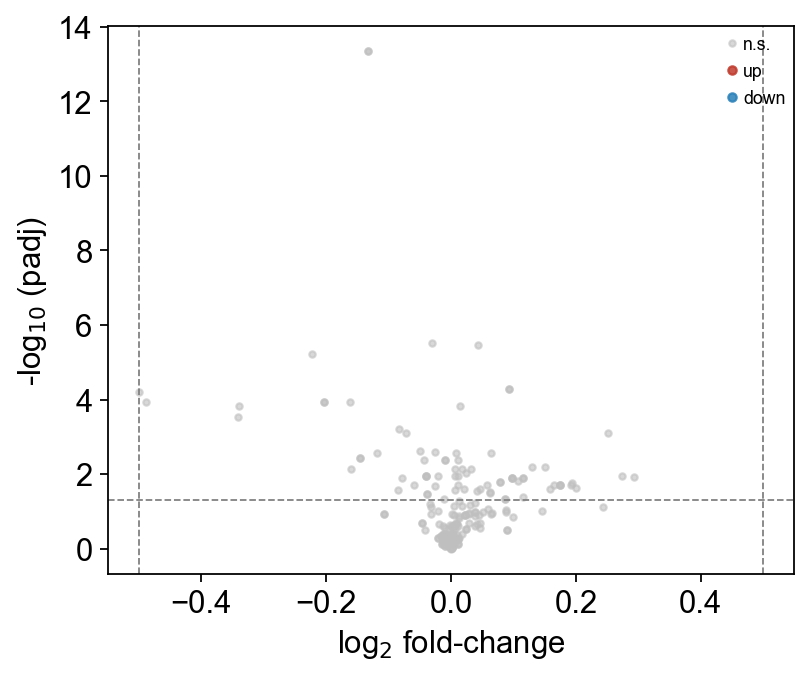

In [12]:
ov.metabol.volcano(deg, padj_thresh=0.05, log2fc_thresh=0.5, label_top_n=8)
plt.show()


## 6 — Multivariate discrimination

**PLS-DA** + **OPLS-DA** with leave-one-out Q² on the Pareto-scaled
matrix. OPLS-DA adds the orthogonal-noise split that makes loadings
interpretable; feed its result into `s_plot` (predictive-covariance
vs correlation) and `vip_bar` for the Top-VIP ranking.


In [13]:
pls = ov.metabol.plsda(
    adata_pareto, group_col='group',
    group_a='diabetes mellitus', group_b='Control Group',
    n_components=2,
)
opls = ov.metabol.opls_da(
    adata_pareto, group_col='group',
    group_a='diabetes mellitus', group_b='Control Group',
    n_ortho=1,
)
print(f'PLS-DA  R²X={pls.r2x:.3f}  R²Y={pls.r2y:.3f}  Q²={pls.q2:.3f}')
print(f'OPLS-DA R²X={opls.r2x:.3f}  R²Y={opls.r2y:.3f}  Q²={opls.q2:.3f}')


PLS-DA  R²X=0.253  R²Y=0.669  Q²=0.566
OPLS-DA R²X=0.106  R²Y=0.669  Q²=0.566


### OPLS-DA scores, S-plot, and VIP bar

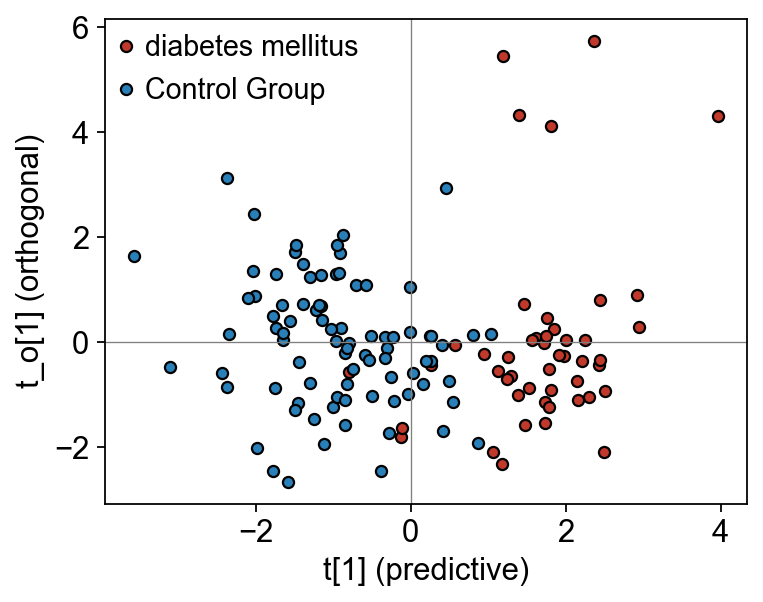

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
for lbl, c in [('diabetes mellitus', '#c0392b'), ('Control Group', '#2980b9')]:
    mask = (adata_pareto.obs['group'] == lbl).to_numpy()
    ax.scatter(opls.scores[mask, 0], opls.x_ortho_scores[mask, 0], c=c, s=25,
               edgecolor='k', label=lbl)
ax.axvline(0, color='grey', lw=0.6); ax.axhline(0, color='grey', lw=0.6)
ax.set_xlabel('t[1] (predictive)'); ax.set_ylabel('t_o[1] (orthogonal)')
ax.legend(frameon=False); fig.tight_layout(); plt.show()


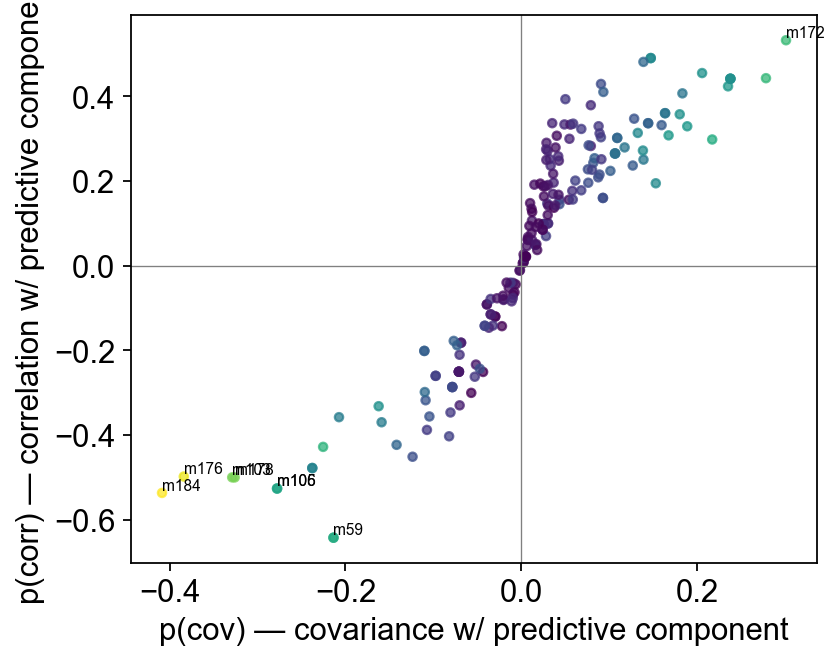

In [15]:
ov.metabol.s_plot(opls, adata_pareto, label_top_n=8)
plt.show()


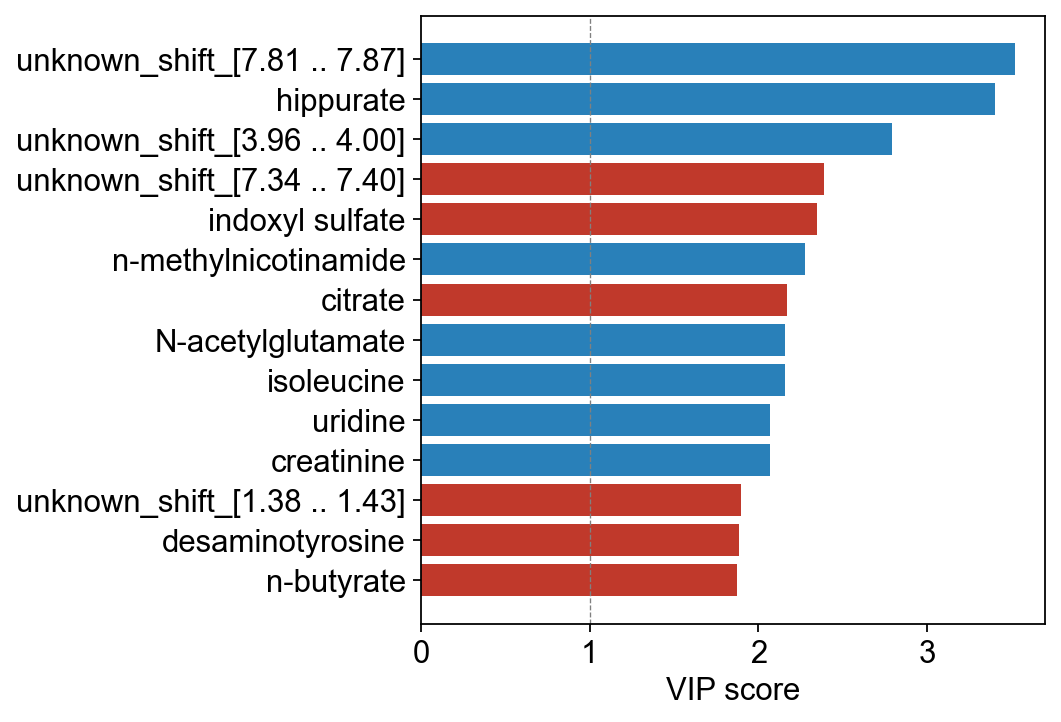

In [16]:
# Use human-readable metabolite names on the VIP bars
mb_names = adata_pareto.var['metabolite_identification'].values
ov.metabol.vip_bar(opls, mb_names, top_n=15)
plt.show()


## 7 — Pathway enrichment (MSEA ORA)

MSEA resolves metabolite names → KEGG IDs. Passing `mass_db=` (v0.5
addition) makes the ChEBI table available as an in-memory lookup —
names present there skip PubChem entirely. Combined with the
cache-on-404 fix in `fetch_hmdb_from_name`, a warm cache run is
about **100× faster** than the cold one.


In [17]:
mass_db = ov.metabol.fetch_chebi_compounds()
hits = deg[deg['padj'] < 0.05].sort_values('padj').head(30).index.tolist()
hit_names = adata_cv.var.loc[hits, 'metabolite_identification'].tolist()
bg_names = adata_cv.var['metabolite_identification'].dropna().tolist()
enr = ov.metabol.msea_ora(hit_names, bg_names, mass_db=mass_db)
print(f'{len(enr)} pathways tested, {(enr["padj"] < 0.05).sum()} padj<0.05')
enr.sort_values('padj').head(5)[['pathway', 'overlap', 'set_size', 'odds_ratio', 'padj']]


18 pathways tested, 0 padj<0.05


                                       pathway  overlap  set_size  odds_ratio  \
0              2-Oxocarboxylic acid metabolism        3         5    6.857143   
1                  Biosynthesis of amino acids        3         5    6.857143   
2                             ABC transporters        2         3    8.250000   
3  Valine, leucine and isoleucine biosynthesis        2         3    8.250000   
4   Valine, leucine and isoleucine degradation        2         4    4.000000   

       padj  
0  0.560631  
1  0.560631  
2  0.560631  
3  0.560631  
4  0.658375  

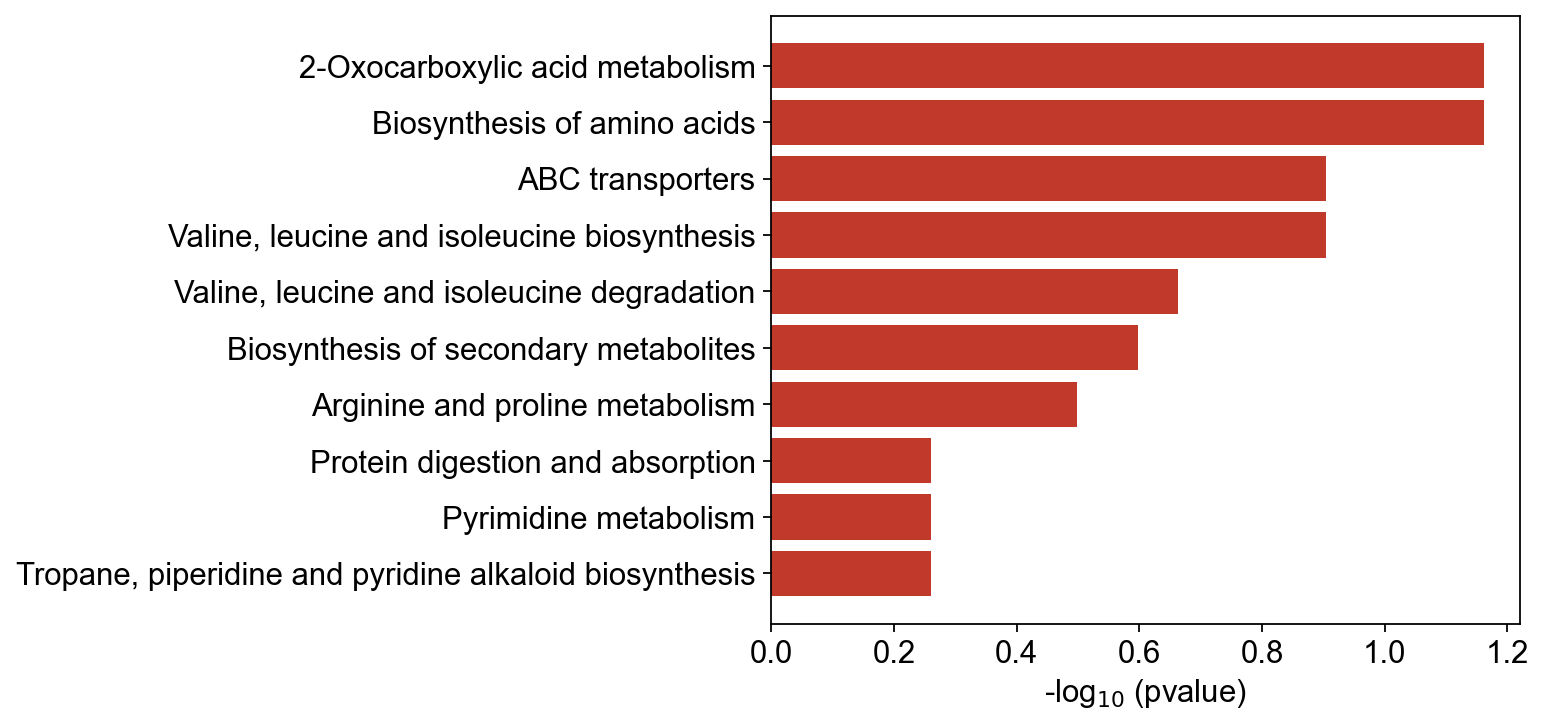

In [18]:
ov.metabol.pathway_bar(enr, top_n=10)
plt.show()


## 8 — Multi-factor decomposition (ASCA)

ASCA decomposes the centred data into per-factor effect matrices
plus interactions plus residual. On MTBLS1 we have **group** (T2D
vs control) and **gender** — and ASCA quantifies how much variance
each explains globally.


In [19]:
asca = ov.metabol.asca(
    adata_pareto,
    factors=['group', 'Factor Value[Gender]'],
    include_interactions=True,
    n_permutations=100,
    seed=0,
)
asca.summary().round(4)


                       effect         ss   df  variance_explained  p_value
0                       group   204.6645  1.0              0.0670   0.0099
1        Factor Value[Gender]   235.3499  1.0              0.0770   0.0099
2  group:Factor Value[Gender]    56.1278  1.0              0.0184   0.0198
3                    residual  2602.8727  NaN              0.8519      NaN

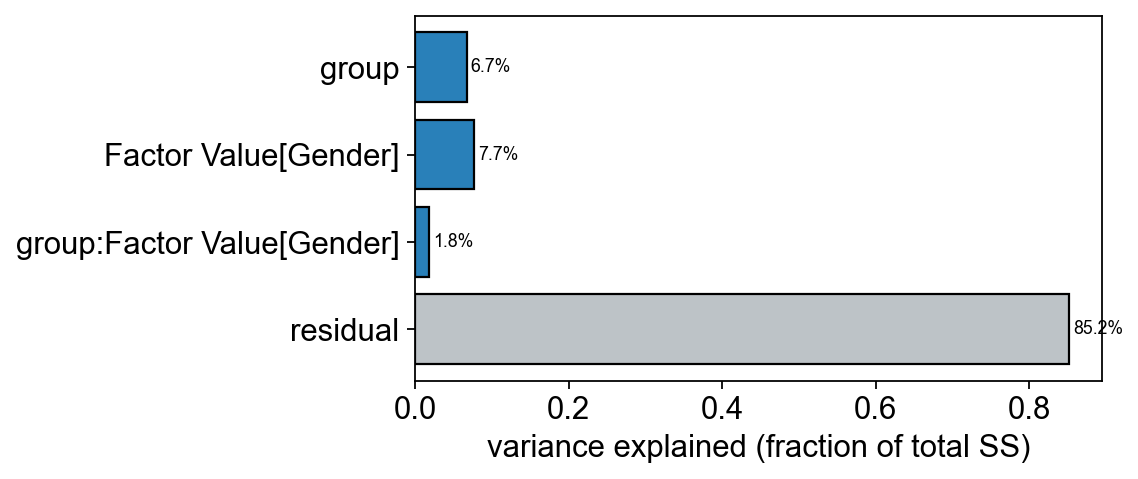

In [20]:
ov.metabol.asca_variance_bar(asca)
plt.show()


## 9 — Biomarker discovery: per-feature ROC + nested-CV panel

**`roc_feature`** gives polarity-invariant per-feature AUC.
**`biomarker_panel`** runs a multivariate nested CV (5-outer × 3-inner
L2 logistic regression here) on the top-10 features with a 100-
permutation null.


In [21]:
auc = ov.metabol.roc_feature(
    adata_log, group_col='group',
    pos_group='diabetes mellitus', neg_group='Control Group',
)
top_auc = auc.head(10).copy()
top_auc['name'] = adata_cv.var.loc[top_auc.index, 'metabolite_identification'].values
top_auc[['name', 'auc']]


                              name       auc
m60              N-acetylglutamate  0.901166
m59                     isoleucine  0.901166
m30               2-oxoisovalerate  0.815972
m31                        ethanol  0.815972
m184  unknown_shift_[7.81 .. 7.87]  0.766369
m117          n-methylnicotinamide  0.758681
m176                     hippurate  0.758185
m178                     hippurate  0.757192
m103  unknown_shift_[3.96 .. 4.00]  0.748760
m127  unknown_shift_[5.33 .. 5.36]  0.743056

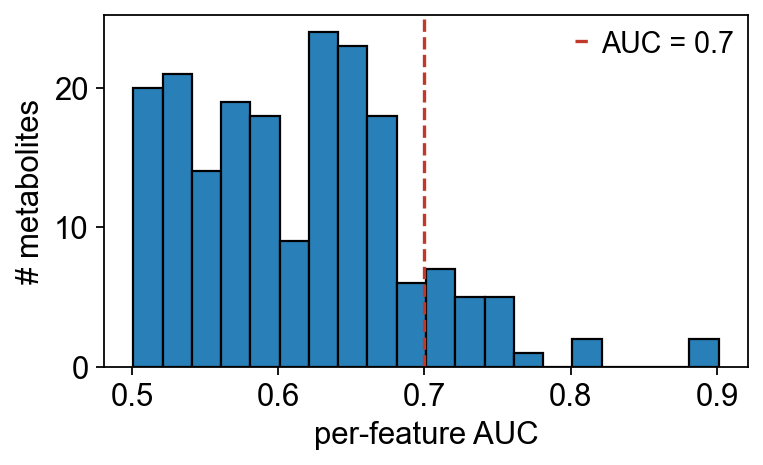

22 metabolites with AUC ≥ 0.7


In [22]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.hist(auc['auc'], bins=20, color='#2980b9', edgecolor='k')
ax.axvline(0.7, color='#c0392b', ls='--', label='AUC = 0.7')
ax.set_xlabel('per-feature AUC'); ax.set_ylabel('# metabolites')
ax.legend(frameon=False); fig.tight_layout(); plt.show()
print(f'{(auc["auc"] >= 0.7).sum()} metabolites with AUC ≥ 0.7')


In [23]:
panel = ov.metabol.biomarker_panel(
    adata_log, group_col='group',
    pos_group='diabetes mellitus', neg_group='Control Group',
    features=10, classifier='lr',
    cv_outer=5, cv_inner=3, n_permutations=100, seed=0,
)
print(f'nested CV AUC: {panel.mean_auc:.3f} ± {panel.std_auc:.3f}')
print(f'permutation p-value: {panel.permutation_pvalue:.3f}')


nested CV AUC: 0.946 ± 0.037
permutation p-value: 0.010


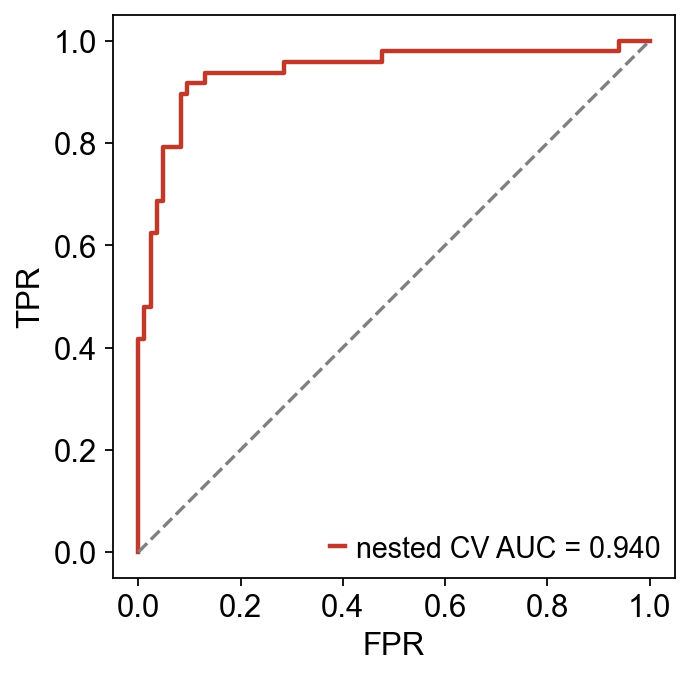

In [24]:
from sklearn.metrics import roc_curve, auc as _auc
fpr, tpr, _ = roc_curve(panel.outer_labels, panel.outer_predictions)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(fpr, tpr, color='#c0392b', lw=2, label=f'nested CV AUC = {_auc(fpr, tpr):.3f}')
ax.plot([0, 1], [0, 1], ls='--', color='grey')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_aspect('equal')
ax.legend(loc='lower right'); fig.tight_layout(); plt.show()


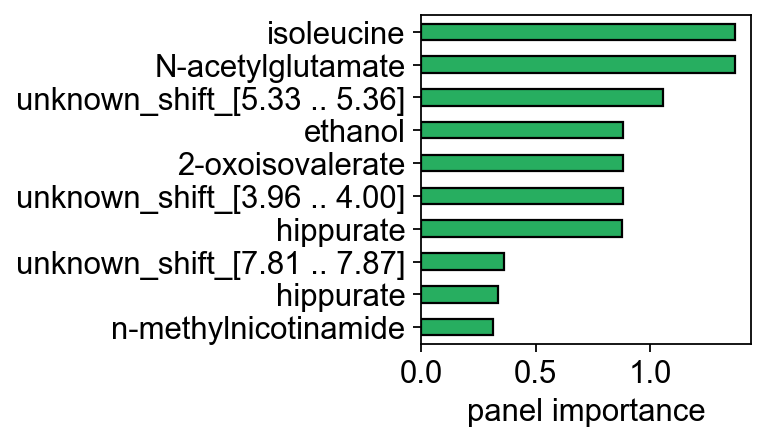

In [25]:
fig, ax = plt.subplots(figsize=(5, 3))
imp = panel.feature_importance
imp.index = adata_cv.var.loc[imp.index, 'metabolite_identification'].values
imp.iloc[::-1].plot.barh(ax=ax, color='#27ae60', edgecolor='k')
ax.set_xlabel('panel importance'); ax.set_ylabel('')
fig.tight_layout(); plt.show()


## 10 — Differential correlation (DGCA) + static network

DGCA classifies every metabolite-pair correlation as one of
`+/+ -/- +/- -/+ +/0 0/+ -/0 0/- 0/0`. The class-count bar shows
the overall rewiring landscape; the `corr_network` network plot on
the T2D condition reveals the backbone that survives the
|r| ≥ 0.5 filter.


In [26]:
dc = ov.metabol.dgca(
    adata_log, group_col='group',
    group_a='diabetes mellitus', group_b='Control Group',
    method='spearman',
)
print(f'{len(dc)} pairs, {(dc["padj"] < 0.05).sum()} padj<0.05')
dc.sort_values('padj').head(5)[['feature_a', 'feature_b', 'r_a', 'r_b', 'z_diff', 'padj']]


18721 pairs, 2887 padj<0.05


   feature_a feature_b       r_a       r_b     z_diff      padj
0       m149      m150  1.000000  0.999656  40.478362  0.000000
1       m148      m218 -0.212657  0.749357  -6.386681  0.000002
8        m51       m59 -0.029744  0.784732  -5.848193  0.000006
10       m68      m198  0.207013 -0.709142   5.892204  0.000006
14      m148      m210 -0.111919  0.762155  -5.990206  0.000006

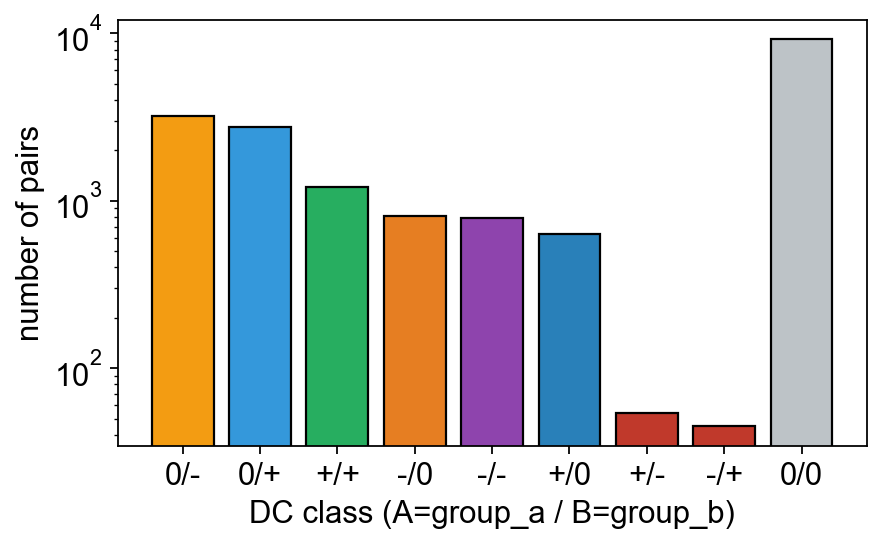

In [27]:
ov.metabol.dgca_class_bar(dc)
plt.show()


In [28]:
edges_t2d = ov.metabol.corr_network(
    adata_log,
    group_col='group', group='diabetes mellitus',
    method='spearman',
    abs_r_threshold=0.5, padj_threshold=0.05,
)
print(f'{len(edges_t2d)} edges in T2D network (|r|≥0.5, padj<0.05)')


740 edges in T2D network (|r|≥0.5, padj<0.05)


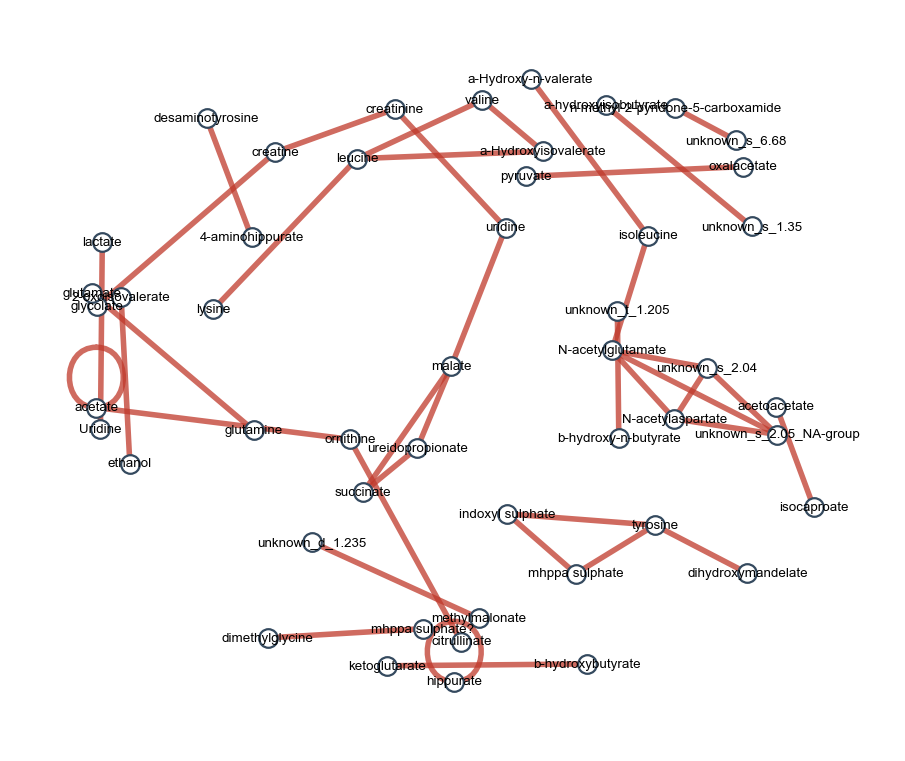

In [29]:
named = adata_cv.var['metabolite_identification'].to_dict()
edges_plot = edges_t2d.copy()
edges_plot['feature_a'] = edges_plot['feature_a'].map(named).fillna(edges_plot['feature_a'])
edges_plot['feature_b'] = edges_plot['feature_b'].map(named).fillna(edges_plot['feature_b'])
top = edges_plot.head(40)
ov.metabol.corr_network_plot(top, figsize=(7, 6), label_font_size=6)
plt.show()


## 11 — Pipeline summary

| Step | Status on MTBLS1 | Plot shown |
|---|---|---|
| `ov.utils.load_metabolights` | ✓ | — |
| exploratory bar chart | ✓ | 1 (group × gender) |
| `cv_filter(across='all')` | ✓ | — |
| `sample_qc` + `sample_qc_plot` | ✓ | 1 (T² vs DModX) |
| missing-value histograms | ✓ | 1 (two panels) |
| raw vs PQN box | ✓ | 1 |
| `impute / normalize / transform` | ✓ | — |
| `differential` + `volcano` | ✓ | 1 (volcano) |
| `plsda` / `opls_da` / `s_plot` / `vip_bar` | ✓ | 3 |
| `msea_ora(mass_db=)` + `pathway_bar` | ✓ | 1 |
| `asca` + `asca_variance_bar` | ✓ | 1 |
| `roc_feature` + AUC histogram | ✓ | 1 |
| `biomarker_panel` + fold ROC + feature-importance bar | ✓ | 2 |
| `dgca` + `dgca_class_bar` | ✓ | 1 |
| `corr_network` + `corr_network_plot` | ✓ | 1 |
| `drift_correct`, `serrf` | ✗ (no QC pool) | — |
| `mixed_model`, `meba` | ✗ (cross-sectional) | — |
| `run_mofa` | ✗ (mono-omic) | — |

**~15 plots across the pipeline.** Every plot cell uses one
visualization helper from `ov.metabol.*` (or a 3-line matplotlib
snippet for the one-off summaries) so each cell stays under five
callable references.
